# EMS515U: Coursework 2023-24

<div class="alert alert-block alert-danger">
<b>IMPORTANT</b> Before you submit your solutions, make sure everything runs as expected. To do so, in the menubar, select Kernel -> Restart Kernel and Clear. This will clear the memory and remove all outputs from the screen.

Then, it is recommeneded that you manually run each cell to ensure the results are error-free and, more importantly, what you expect to see.
</div>

## INSTRUCTIONS
- Make sure you enter code in cells that say `YOUR CODE HERE`. You may create more cells as needed.

- In addition, you can explain your work in text/writing using "markdown" cells to type in your responses. Please make use of $\LaTeX$ formatting for math equations where relevant. You can refer to the previous problem sets to do so. Again, you should enter your responses in the cells that say "YOUR ANSWER HERE".

# Problem Statement 1
In Week 6, a tutorial was presented that showed how to:
1. solve a system of ordinary differential equations of first order numerically using `solve_ivp`.
2. generate plots after "solving" the differential equations using `matplotlib.pyplot`.
In that tutorial, the equations of motion described the dynamics of a simple pendulum. In this problem, you will investigate the motion of a satellite orbiting the Earth. This is modelled as a two-body dynamics system. A brief outline of what you need to do in this problem set is below and that is followed by a systematic set of questions towards achieving specific objectives. You will find the tutorial a handty reference here.

In this problem, you will have to first create a Python function called `twobody_dyanmics_first_order_EoMS`. Given a time $t$ and a state vector $X$, this function will `return` the derivatives of the state vector. Mathematically, this means you are computing $\dot {\bf X}$ using some dynamics equation $\dot {\bf X} = {\bf f}(t,{\bf X})$.

Once you have this function in Python, you can solve the differential equations it contains by using `solve_ivp`. The command will be similar to, but not necessarily exactly, what is shown below:

`solve_ivp(simple_pendulum_first_order_EoMS, t_span, initial_conditions, args=constants, rtol = 1e-8, atol = 1e-8)`

which integrates the differential equations of motion to give us solutions to the states (i.e., position and velocity of a satellite). In the above, `t_span` contains the initial time $t_0$ and final time $t_f$ and it will compute the solution at every instant of time (you will define this later in Problem 1.3 below).

The integration is done with initial state vector $X_0$ which defines the initial position and velocity. $X_0$ needs to be a column vector.

You will need to use the following constants in arriving at your answers:
- Earth gravitational parameter = $3.986 \times 10^5$  $km^3/s^2$ 
- Earth mean radius = $6378.14$ $km$


# Question 1.1 (5 marks)
Write down the two body equations of motion in 3D, as a system of differential equations in the form $\dot {\bf X} = f({\bf X})$, where
$$
{\bf X} =
\begin{bmatrix}
    x \\
    y \\
    z \\
    \dot x\\
    \dot y\\
    \dot z\\
\end{bmatrix} =
\begin{bmatrix}
    X_1 \\
    X_2 \\
    X_3 \\
    X_4\\
    X_5\\
    X_6\\
\end{bmatrix}
\tag{1.1}
$$
and
$$
\dot {\bf X} =
\begin{bmatrix}
    \dot x \\
    \dot y \\
    \dot z \\
    \ddot x\\
    \ddot y\\
    \ddot z\\
\end{bmatrix} =
\begin{bmatrix}
    X_4 \\
    X_5 \\
    X_6 \\
    f_1(X_1, X_2, X_3)\\
    f_2(X_1, X_2, X_3)\\
    f_3(X_1, X_2, X_3)\\
\end{bmatrix}
\tag{1.2}
$$ 


# Answer 1.1 (double-click to edit this text)
$$
\dot {\bf X} =
\begin{bmatrix}
    \dot X_1 \\
    \dot X_2 \\
    \dot X_3 \\
    \dot X_4\\
    \dot X_5\\
    \dot X_6\\
\end{bmatrix} =
\begin{bmatrix}
    X_4 \\
    X_5 \\
    X_6 \\
    -\frac{\mu}{r^3} X_1\\
    -\frac{\mu}{r^3} X_2\\
    -\frac{\mu}{r^3} X_3\\
\end{bmatrix}
\tag{1.2}
$$

# Problem 1.2 (5 points)
Write the function with the following name `twobody_dynamics_first_order_EoMs(t, states)` that describes the equations of motion you have derived above in Question 1.1. `states` represents the 6-dimensional column vector $X$ in Equation $(1.1)$.

In [1]:
mu = 3.986e5

def twobody_dynamics_first_order_EoMs(t, states):
    x1, x2, x3, x4, x5, x6 = states
    r = sqrt(x1**2 + x2**2 + x3**2)
    x1_dot = x4
    x2_dot = x5
    x3_dot = x6
    x4_dot = (-mu/r**3)*x1
    x5_dot = (-mu/r**3)*x2
    x6_dot = (-mu/r**3)*x3
    return [x1_dot, x2_dot, x3_dot, x4_dot, x5_dot, x6_dot]

# Problem 1.2 (10 marks)
Use `solve_ivp` to integrate the equations of motion of the two-body problem. The initial position and velocity state vector ${\bf X}_0= ({\bf r},{\bf v})^T$ is:
$$
{\bf r} = \begin{bmatrix}
6510.75986901532\\
2676.16546382759\\
333.334029373109\\
\end{bmatrix} km
$$
and
$$
{\bf v} = \begin{bmatrix}
-2.23202460862428\\
          9.49860960555864\\
          1.18311436869621\\
\end{bmatrix} km/s
$$
The duration of the simulation is for one day but you should compute the solutuion for every ten seconds. We show you how to control this below but you will have to make changes to this code to get it to work correctly for this simiualtion.

Lastly, when using `solve_ivp` make sure that you use `rtol=1e-12` and `atol = 1e-12`.

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from math import pi, sin, cos, sqrt
import matplotlib.pyplot as plotter

In [3]:
# make changes as relevant
simulation_duration = 24*60*60 # in seconds
t_span = (0.0, simulation_duration)
dt = 10 # seconds
t = np.arange(0.0, simulation_duration, dt)
# write code that uses solve_ivp below this line

In [4]:
initial_conditions = (6510.75986901532, 2676.16546382759, 333.334029373109, -2.23202460862428, 9.49860960555864, 1.18311436869621) # r_vec_0, v_vec_0
numerical_solution_to_differential_equations = solve_ivp(twobody_dynamics_first_order_EoMs, t_span,initial_conditions, t_eval=t, rtol = 1e-8, atol = 1e-8)

# Problem 1.3 (10 points)
Plot the magnitude of the position vector versus time. The x-axis must show time (in hours) and y axis must show the radius (in $km$).


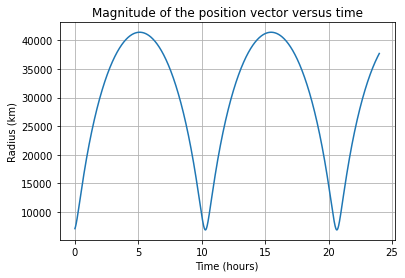

In [5]:
time_values = numerical_solution_to_differential_equations.t
r_vec = np.sqrt(numerical_solution_to_differential_equations.y[0]**2 + numerical_solution_to_differential_equations.y[1]**2 + numerical_solution_to_differential_equations.y[2]**2)
plotter.plot(time_values/3600, r_vec)
plotter.xlabel('Time (hours)')
plotter.ylabel('Radius (km)')
plotter.title('Magnitude of the position vector versus time')
plotter.grid()
plotter.show()

# Problem 1.4 (10 points)
Plot the magnitude of the velocity vector versus time. The x-axis must show time (in hours) and y axis must show the radius (in $km/s$).


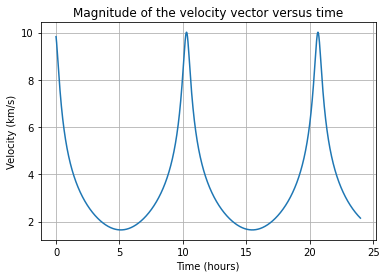

In [6]:
v_vec = np.sqrt(numerical_solution_to_differential_equations.y[3]**2 + numerical_solution_to_differential_equations.y[4]**2 + numerical_solution_to_differential_equations.y[5]**2)
plotter.plot(time_values/3600, v_vec)
plotter.xlabel('Time (hours)')
plotter.ylabel('Velocity (km/s)')
plotter.title('Magnitude of the velocity vector versus time')
plotter.grid()
plotter.show()

# Problem 1.5 (10 points)
Plot the orbit in 3D using a suitably dimensioned sphere for the Earth.


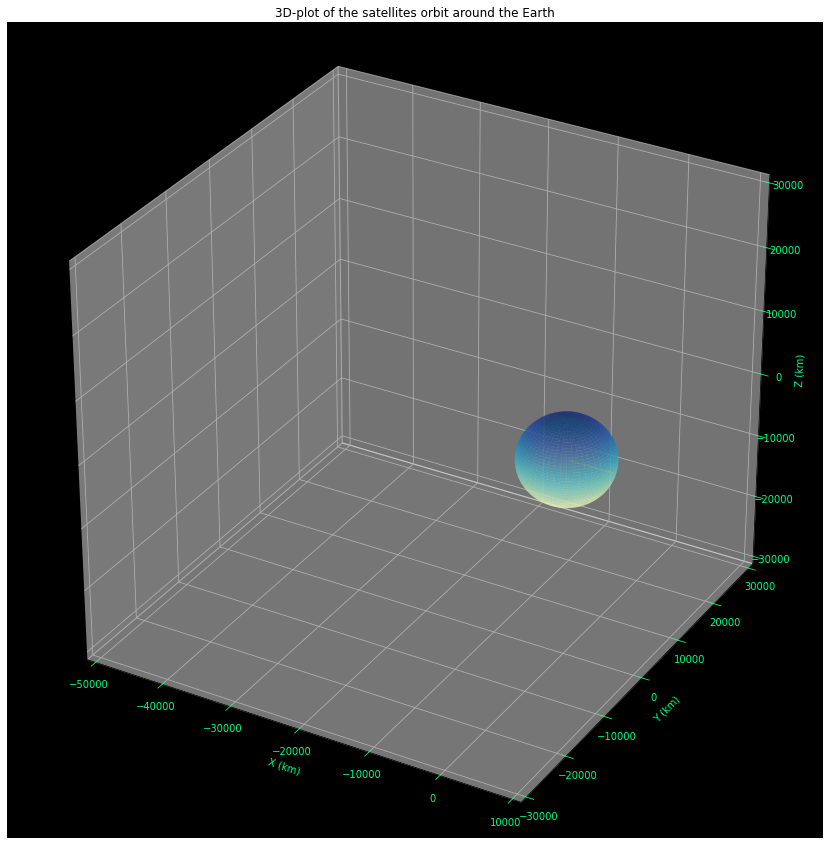

In [25]:
import matplotlib.pyplot as plt
# Define the radius of the Earth
earth_radius = 6378.14
fig = plt.figure(figsize=(25,15))
ax = fig.add_subplot(111, projection='3d', facecolor='black')

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = earth_radius * np.outer(np.cos(u), np.sin(v))
y = earth_radius * np.outer(np.sin(u), np.sin(v))
z = earth_radius * np.outer(np.ones(np.size(u)), np.cos(v))

# Plot the surface
ax.plot_surface(x, y, z, label='Earth', cmap=plt.cm.YlGnBu, alpha=0.65)
# ax.plot_surface(x, y, z, label='Earth', color='#00FF00', alpha=0.5, edgecolors='#0055FF')
# Set an equal aspect ratio
ax.set_aspect('equal')
# Plot the orbit
ax.plot(numerical_solution_to_differential_equations.y[0], numerical_solution_to_differential_equations.y[1], numerical_solution_to_differential_equations.y[2], label='Satelite Orbit', color='orange')

plt.title('3D-plot of the satellites orbit around the Earth')
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
#set limits for axes:
ax.set_xlim(-50000, 10000)
ax.set_ylim(-30000, 30000)
ax.set_zlim(-30000, 30000)

#Changing the color of the axes
ax.tick_params(axis='x', colors='springgreen')
ax.tick_params(axis='y', colors='springgreen')
ax.tick_params(axis='z', colors='springgreen')
ax.xaxis.label.set_color('springgreen')
ax.yaxis.label.set_color('springgreen')
ax.zaxis.label.set_color('springgreen')

plt.show()

# Problem 1.6 (5 marks)
Plot the Specific Energies (i.e., all three Kinetic, Potential and Total Energy) in the same plot as a function of time. The x-axis must show time (in hours) and y axis must show the Energy (in $km^2/s^2$).

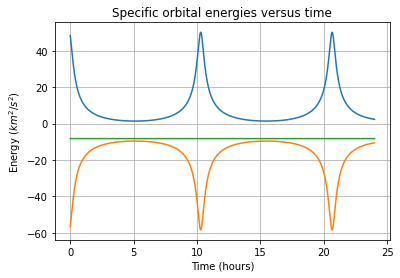

In [8]:
kinetic_E = (v_vec**2)/2 # kinetic energy
potential_E = - mu/r_vec # potential energy
total_E = kinetic_E + potential_E # total energy

plotter.plot(time_values/3600, kinetic_E)
plotter.plot(time_values/3600, potential_E)
plotter.plot(time_values/3600, total_E)
plotter.xlabel('Time (hours)')
plotter.ylabel('Energy $(km^2/s^2)$')
plotter.title('Specific orbital energies versus time')
plotter.grid()
plotter.show()

# Problem 1.6 (5 marks)
Plot the Specific Angular Momentum as a function of time. The x-axis must show time (in hours) and y axis must show the momentum (in $km^2/s$).

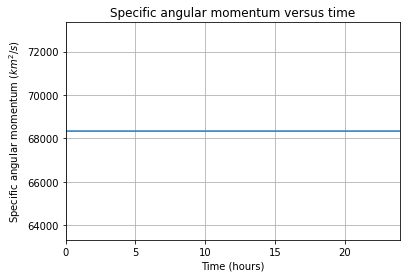

In [9]:
r_column_vec = numerical_solution_to_differential_equations.y[0:3]
v_column_vec = numerical_solution_to_differential_equations.y[3:6]
h_vec = np.cross(r_column_vec, v_column_vec, axis=0)
h_mag = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2)
plotter.plot(time_values/3600, h_mag)
plotter.xlabel('Time (hours)')
plotter.ylabel('Specific angular momentum $(km^2/s)$')
plotter.ylim(h_mag[0] - 5000, h_mag[0] + 5000)
plotter.xlim(0, time_values[-1]/3600)
plotter.title('Specific angular momentum versus time')
plotter.grid()
plotter.show()

# Problem 1.7 (20 points)
Now, we give you some new initial conditions for the state vecotr ${\bf X}_0$ as below
$$
{\bf r} = \begin{bmatrix}
6628\\
0\\
0\\
\end{bmatrix} km
$$
and
$$
{\bf v} = \begin{bmatrix}
0\\
0\\
0\\
\end{bmatrix} km/s
$$

As before, make use of `solve_ivp` to determine the type of orbit this represents. You should support your conclusions with plots of radial distance and velocity over at least one day. Also, determine the following:
- orbit period
- semi-major axis and
- inclination.

Hints:
1. Recall that the Orbital Specific Energy $E=-\frac{\mu}{2a}$ where $a$ is the semi-major axis.
2. The inclination of a satellite’s orbit is the angle between the direction of its angular momentum vector and the z-axis.


In [10]:
initial_conditions = (6628, 0, 0, 0, 0, 0) # r_vec_0, v_vec_0
# initial_conditions = (8008.99432909027, 0, 0, 0, 0, 7.07656870281654) # r_vec_0, v_vec_0
numerical_solution_to_differential_equations = solve_ivp(twobody_dynamics_first_order_EoMs, t_span,initial_conditions, t_eval=t, rtol = 1e-8, atol = 1e-8)

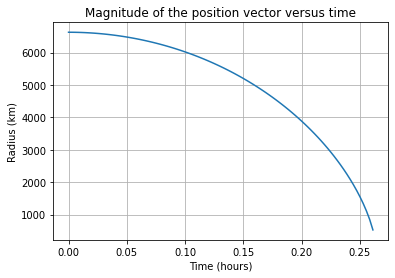

In [11]:
time_values = numerical_solution_to_differential_equations.t
r_vec = np.sqrt(numerical_solution_to_differential_equations.y[0]**2 + numerical_solution_to_differential_equations.y[1]**2 + numerical_solution_to_differential_equations.y[2]**2)
plotter.plot(time_values/3600, r_vec)
plotter.xlabel('Time (hours)')
plotter.ylabel('Radius (km)')
plotter.title('Magnitude of the position vector versus time')
plotter.grid()
plotter.show()

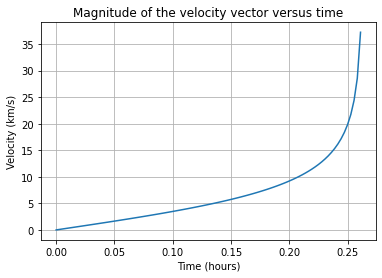

In [12]:
v_vec = np.sqrt(numerical_solution_to_differential_equations.y[3]**2 + numerical_solution_to_differential_equations.y[4]**2 + numerical_solution_to_differential_equations.y[5]**2)
plotter.plot(time_values/3600, v_vec)
plotter.xlabel('Time (hours)')
plotter.ylabel('Velocity (km/s)')
plotter.title('Magnitude of the velocity vector versus time')
plotter.grid()
plotter.show()

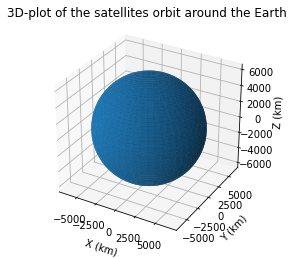

In [13]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = earth_radius * np.outer(np.cos(u), np.sin(v))
y = earth_radius * np.outer(np.sin(u), np.sin(v))
z = earth_radius * np.outer(np.ones(np.size(u)), np.cos(v))

# Plot the surface
ax.plot_surface(x, y, z)
# ax.plot_wireframe(x, y, z,rstride=10, cstride=10)

# Plot the orbit
ax.plot(numerical_solution_to_differential_equations.y[0], numerical_solution_to_differential_equations.y[1], numerical_solution_to_differential_equations.y[2])

# Set an equal aspect ratio
ax.set_aspect('equal')
plt.title('3D-plot of the satellite''s orbit around the Earth')
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

plt.show()

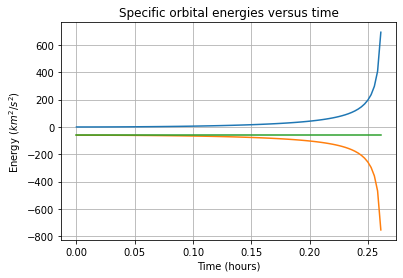

In [14]:
kinetic_E = (v_vec**2)/2 # kinetic energy
potential_E = - mu/r_vec # potential energy
total_E = kinetic_E + potential_E # total energy

plotter.plot(time_values/3600, kinetic_E)
plotter.plot(time_values/3600, potential_E)
plotter.plot(time_values/3600, total_E)
plotter.xlabel('Time (hours)')
plotter.ylabel('Energy $(km^2/s^2)$')
plotter.title('Specific orbital energies versus time')
plotter.grid()
plotter.show()

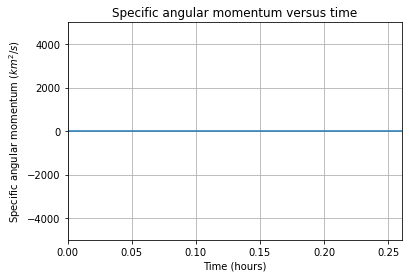

In [15]:
r_column_vec = numerical_solution_to_differential_equations.y[0:3]
v_column_vec = numerical_solution_to_differential_equations.y[3:6]
h_vec = np.cross(r_column_vec, v_column_vec, axis=0)
h_mag = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2)
plotter.plot(time_values/3600, h_mag)
plotter.xlabel('Time (hours)')
plotter.ylabel('Specific angular momentum $(km^2/s)$')
plotter.ylim(h_mag[0] - 5000, h_mag[0] + 5000)
plotter.xlim(0, time_values[-1]/3600)
plotter.title('Specific angular momentum versus time')
plotter.grid()
plotter.show()

# Problem Statement 2
The international space station (ISS) orbits the Earth with a crew of astronauts living onboard. To provide them food and water, a Cargo Dragon capsule is sent to the ISS $3$ to $4$ times annualy. After delivering supplies, this capsule is filled with waste and de-orbited. Your mission is to determine the orbit parameters for the capsule, catch up and dock with the ISS, and apply the correct change in velocity to de-orbit it and cause it to burn-up upon re-entry to the Earth’s atmosphere.

To simplify the problem, we assume that the ISS is in a circular, equatorial orbit at an altitude of $404$ $km$ above the Earth. The Cargo Dragon capsule is placed in an equatorial orbit with an eccentricity such that it will intercept the ISS at apogee, i.e. the apogee of the capsule orbit coincides with the orbital radius of the ISS. Initially the angular separation between the capsule and the ISS is $\Delta \Theta$, with the ISS being $\Delta \Theta$ radians ahead of the capsule. This scenario is illustrated in the Figure below where, the blue orbit (solid line) is for the ISS and the green orbit (dashed line) is for the cargo delivery capsule.

<div>
<img src="ISSchaserDiagram.png" width="300"/>
</div>

Due to the different semi-major axes, the two spacecraft have different orbital periods and in particular the orbital period of the capsule is shorter than that of the ISS. The semi-major axis of the capsule satellite is selected such that it catches up with the ISS in $N_{rev}$ orbits.
To enforce this condition, the following equation can be written
$$
N_{rev}  T_{capsule} (n_{capsule} - n_{ISS})= \Delta \Theta
\tag{2.1}
$$
where $T_{capsule}$ is the orbital period of the capsule and $n_{capsule}$ and $n_{ISS}$ are the mean motion of the capsule and ISS, respectively. Equation $(2.1)$ below basically states that the relative angular velocity (i.e., $n_{capsule} -n_{ISS}$) must be chosen such that the angular separation between $\delta \Theta$ goes to zero in an interval of time $N_{rev} T_{capsule}$.

By substituting the expressions for the mean motion and orbital period into Equation $(2.1)$, it can be found that:
$$
a_{capsule} = \bigg(1- \frac{\Delta \Theta}{2\pi N_{rev}} \bigg)^{\frac{2}{3}} a_{ISS}
\tag{2.2}
$$
Finally, noting that the apogee of the capsule is equal to the orbital radius of the ISS, the value of the eccentricity of the capsule orbit can be calculated:
$$
e_{capsule}= \frac{a_{ISS}}{a_{capsule}} -1.0
\tag{2.3}
$$

# Question 2.1 (5 marks)
Calculate the initial state vector $X_0 = ({\bf r}, {\bf v})^T$ of the ISS using the coordinate system as in the Figure above and with $\Delta \theta = 120^o$. Then, plot the orbit using ``solve_ivp``. What is the orbit period?

In [16]:
r_ISS = earth_radius + 404

theta_in_degrees = 120
theta_in_radians = theta_in_degrees*pi/180
v_ISS_circular = sqrt(mu/r_ISS)

r_vec_ISS = [r_ISS*cos(theta_in_radians), r_ISS*sin(theta_in_radians), 0]
v_vec_ISS = [-v_ISS_circular*sin(theta_in_radians), v_ISS_circular*cos(theta_in_radians), 0]
x_vec_ISS = r_vec_ISS + v_vec_ISS # ISS inital state vector

T_ISS = 2*pi*sqrt(r_ISS**3/mu)

In [17]:
print("the initial state vector of the ISS is: ", x_vec_ISS)
print("The orbital period of the ISS is: ", T_ISS, " seconds")

the initial state vector of the ISS is:  [-3391.069999999999, 5873.505532022594, 0, -6.63920232489594, -3.833145249483058, 0]
The orbital period of the ISS is:  5558.547827659523  seconds


# Question 2.2 (10 marks)
Using Equations (2.2) and (2.3) above, calculate the semi-major axis and eccentricity required to intercept the ISS after $20$ orbits. Calculate the initial state vector $X_0 = ({\bf r}, {\bf v})^T$  for the cargo capsule. Propagate the orbit to plot the distance between the ISS and capsule as the latter catches up.

In [18]:
n_orbit = 20
a_chaser = (1- theta_in_radians/(2*pi*n_orbit))**(2/3)*r_ISS
e_chaser = r_ISS/a_chaser - 1
perigee_chaser = a_chaser*(1-e_chaser)
apogee_chaser = r_ISS
print("The perigee of the chaser is: ", perigee_chaser-earth_radius, " km")
print("The apogee of the chaser is: ", apogee_chaser-earth_radius, " km")
print("The semi-major axis of the chaser is: ", a_chaser, " km")
print("The eccentricity of the chaser is: ", e_chaser)

v_chaser_initial = sqrt((2*mu/apogee_chaser) -(mu/a_chaser))
r_chaser_initial_vec = [apogee_chaser, 0, 0]
v_chaser_initial_vec = [0, v_chaser_initial, 0]
x_vec_chaser_initial = r_chaser_initial_vec + v_chaser_initial_vec
print("the initial state vector of the chaser is: ", x_vec_chaser_initial)

T_chaser = 2*pi*sqrt(a_chaser**3/mu)
print("The orbital period of the chaser is: ", T_chaser, " seconds")

The perigee of the chaser is:  252.86399555599291  km
The apogee of the chaser is:  404.0  km
The semi-major axis of the chaser is:  6706.571997777996  km
The eccentricity of the chaser is:  0.01126775381626266
the initial state vector of the chaser is:  [6782.14, 0, 0, 0, 7.6229772054235765, 0]
The orbital period of the chaser is:  5465.905363865197  seconds


In [19]:
# write code that uses solve_ivp below this line
# we need to simulate for as long as it takes for he chaser to complete 20 orbits in catching up to the ISS 
simulation_duration = T_chaser*2*n_orbit # in seconds
# t_span = (0.0, T_chaser*0.8)
t_span = (0.0, simulation_duration)
dt = 10 # seconds
t = np.arange(0.0, t_span[-1], dt)
print(t_span)
numerical_solution_to_differential_equations_ISS = solve_ivp(twobody_dynamics_first_order_EoMs, t_span, x_vec_ISS, t_eval=t, rtol = 1e-8, atol = 1e-8)

(0.0, 218636.21455460787)


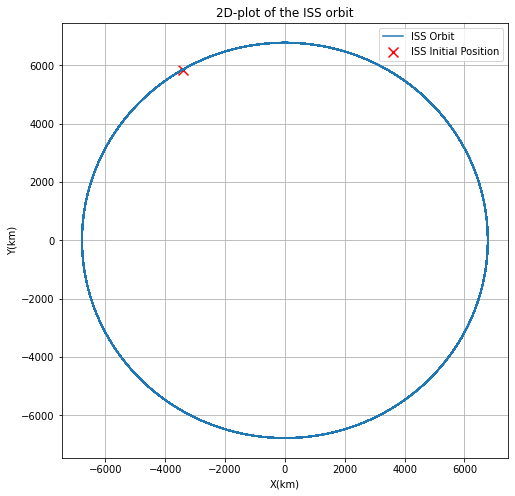

In [20]:
# Plot the surface
r_x_ISS = numerical_solution_to_differential_equations_ISS.y[0]
r_y_ISS = numerical_solution_to_differential_equations_ISS.y[1]

# Plot the orbit
plt.figure(figsize=(8, 8))
plt.plot(r_x_ISS, r_y_ISS, label='ISS Orbit')
plt.xlabel(r'X(km)')
plt.ylabel(r'Y(km)')
plt.title('2D-plot of the ISS orbit')
plt.scatter(r_x_ISS[0], r_y_ISS[1], color='red', label='ISS Initial Position', marker='x', s=100)
plt.legend()
plt.grid(True)
plt.show()

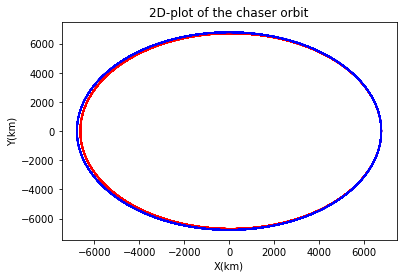

In [21]:
# write code that uses solve_ivp below this line
numerical_solution_to_differential_equations_chaser = solve_ivp(twobody_dynamics_first_order_EoMs, t_span, x_vec_chaser_initial, t_eval=t, rtol = 1e-8, atol = 1e-8)

# Plot the surface
r_x_chaser = numerical_solution_to_differential_equations_chaser.y[0]
r_y_chaser = numerical_solution_to_differential_equations_chaser.y[1]

# Plot the orbit
plt.plot(r_x_chaser, r_y_chaser, 'r--', r_x_ISS, r_y_ISS, 'b-.')
# plt.plot(r_x_chaser, r_y_chaser, 'g--')
plt.xlabel(r'X(km)')
plt.ylabel(r'Y(km)')
plt.title('2D-plot of the chaser orbit')
plt.show()

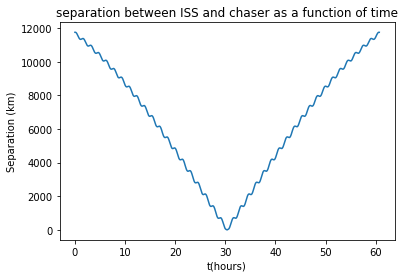

In [22]:
import numpy as np
distance = np.sqrt((r_x_chaser - r_x_ISS)**2 + (r_y_chaser - r_y_ISS)**2)
plt.plot(numerical_solution_to_differential_equations_ISS.t/3600, distance)
plt.xlabel(r't(hours)')
plt.ylabel(r'Separation (km)')
plt.title('separation between ISS and chaser as a function of time')
plt.show()


# Question 2.3 (10 marks)
Calculate, and plot as a graph, the $\Delta V$ required to lower the perigee of the capsule to the range of values $120$ $km$ to $250$ $km$. 

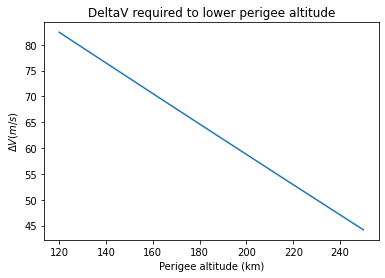

In [23]:
# DeltaV required to lower ISS apogee from 250 to 120 km altitude
r_inc = -1 # seconds
r_new_perigees = np.arange(250, 119, r_inc)
r_new_perigees_with_Earth_Radius = r_new_perigees + earth_radius
semi_major_axis_list = 0.5*(r_new_perigees_with_Earth_Radius + r_ISS)
elliptical_orbit_velocity = np.sqrt(mu*(2/r_ISS - 1/(semi_major_axis_list)))
delta_v = v_ISS_circular - elliptical_orbit_velocity
plt.plot(r_new_perigees, delta_v*1000)
plt.xlabel(r'Perigee altitude (km)')
plt.ylabel(r'$\Delta V (m/s)$')
plt.title('DeltaV required to lower perigee altitude')
plt.show()

# Question 2.4 (10 marks)
The capsule will also need a $\Delta V$ to match its apogee speed to the ISS before it can dock. Write a function that calculates this $\Delta V$ as function of the number of orbits $N_{rev}$ required by the capsule satellite to catch up with the ISS. Plot the values of the $\Delta V$ for $N_rev \epsilon [5,25]$. Comment upon the variation, and the reason, in the $\Delta V$ required.

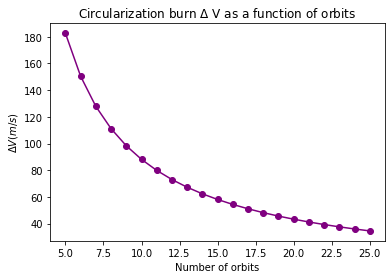

In [24]:
# DeltaV required to lower ISS apogee from 500 to 120 km altitude
r_inc = 1 # seconds
n_orbit = np.arange(5, 26, r_inc)

a_chaser = (1 - theta_in_radians/(2*pi*n_orbit))**(2/3)*r_ISS;

delta_v_chaser = v_ISS_circular - np.sqrt(mu*(2./r_ISS - 1./a_chaser))
plt.plot(n_orbit, delta_v_chaser*1000, marker='o', linestyle='-', color='purple')
plt.xlabel(r'Number of orbits')
plt.ylabel(r'$\Delta V (m/s)$')
plt.title(r'Circularization burn $\Delta$ V as a function of orbits')
plt.show()